# Fintech Payment Operations Analytics
## Problem: $1M+ in annual revenue lost to preventable gateway failures
### Stack: Python (data generation) → MySQL (SQL analysis) → Tableau (visualization)

In [ ]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

# Set random seed for reproducibility
np.random.seed(42)
random.seed(42)

# Configuration
num_rows = 50000
start_date = datetime(2026, 6, 1)

# Dim tables/Categories
currencies = ['INR', 'SAR', 'AED']
gateways = ['Razorpay', 'Checkout.com', 'Stripe', 'Tabby', 'Tamara']
methods = ['UPI', 'Credit_Card', 'Debit_Card', 'Apple_Pay', 'BNPL']
banks_india = ['HDFC', 'ICICI', 'SBI', 'Axis']
banks_ksa = ['Al_Rajhi', 'SNB', 'Riyad_Bank']
banks_uae = ['Emirates_NBD', 'ADCB', 'Mashreq']

error_codes = ['INSUFFICIENT_FUNDS', 'SYSTEM_TIMEOUT', 'AUTH_FAILED', 'GATEWAY_DOWN', 'NONE']
devices = ['iOS', 'Android', 'Web']

data = []

for i in range(num_rows):
    tx_id = f"TXN_{1000000 + i}"
    user_id = f"USR_{random.randint(10000, 25000)}"

    # Generate sequential timestamps over the course of 3 weeks
    timestamp = start_date + timedelta(
        days=random.randint(0, 20),
        hours=random.randint(0, 23),
        minutes=random.randint(0, 59),
        seconds=random.randint(0, 59)
    )

    amount = round(random.uniform(10.0, 5000.0), 2)

    # Geographic and Currency alignment
    currency = random.choice(currencies)
    if currency == 'INR':
        issuing_bank = random.choice(banks_india)
        payment_method = random.choice(['UPI', 'Credit_Card', 'Debit_Card'])
        payment_gateway = random.choice(['Razorpay', 'Stripe'])
    elif currency == 'SAR':
        issuing_bank = random.choice(banks_ksa)
        payment_method = random.choice(['Credit_Card', 'Apple_Pay', 'BNPL'])
        payment_gateway = random.choice(['Checkout.com', 'Tabby', 'Tamara'])
    else: # AED
        issuing_bank = random.choice(banks_uae)
        payment_method = random.choice(['Credit_Card', 'Apple_Pay', 'BNPL'])
        payment_gateway = random.choice(['Checkout.com', 'Stripe', 'Tamara'])

    # Base operational logic for success/failure
    status = np.random.choice(['SUCCESS', 'FAILED', 'REJECTED'], p=[0.82, 0.12, 0.06])

    if status == 'SUCCESS':
        error_code = 'NONE'
    else:
        error_code = random.choice(['INSUFFICIENT_FUNDS', 'SYSTEM_TIMEOUT', 'AUTH_FAILED', 'GATEWAY_DOWN'])

    # Injecting an intentional "Outage" anomaly for our SQL to find later
    # Let's say Checkout.com had a severe timeout issue on June 15th between 14:00 and 14:45 in KSA (SAR)
    if currency == 'SAR' and payment_gateway == 'Checkout.com' and timestamp.day == 15 and timestamp.hour == 14:
        status = 'FAILED'
        error_code = 'SYSTEM_TIMEOUT'

    device_type = random.choice(devices)

    data.append([
        tx_id, user_id, timestamp, amount, currency,
        payment_method, payment_gateway, issuing_bank,
        status, error_code, device_type
    ])

# Create DataFrame
columns = [
    'transaction_id', 'user_id', 'timestamp', 'amount', 'currency',
    'payment_method', 'payment_gateway', 'issuing_bank',
    'status', 'error_code', 'device_type'
]
df = pd.DataFrame(data, columns=columns)

# Sort by timestamp to mimic a real log file
df = df.sort_values(by='timestamp').reset_index(drop=True)

# Save to CSV
df.to_csv('fintech_transaction_logs.csv', index=False)
print(f"Successfully generated {len(df)} production-grade transaction logs!")

Successfully generated 50000 production-grade transaction logs!


In [ ]:
print("=== PAYMENT OPERATIONS OVERVIEW ===")
print(f"Total transactions: {len(df):,}")
print(f"Date range: {df['timestamp'].min().date()} → {df['timestamp'].max().date()}")
print(f"Markets: {df['currency'].unique()}")
print(f"\nOverall success rate: {(df['status']=='SUCCESS').mean()*100:.2f}%")
print(f"\nSuccess rate by gateway:")
print(df.groupby('payment_gateway')['status']
      .apply(lambda x: f"{(x=='SUCCESS').mean()*100:.2f}%"))

=== PAYMENT OPERATIONS OVERVIEW ===
Total transactions: 50,000
Date range: 2026-06-01 → 2026-06-21
Markets: ['SAR' 'AED' 'INR']

Overall success rate: 82.12%

Success rate by gateway:
payment_gateway
Checkout.com    81.70%
Razorpay        82.42%
Stripe          82.20%
Tabby           82.44%
Tamara          82.05%
Name: status, dtype: object


In [ ]:
exchange = {'INR': 0.012, 'SAR': 0.27, 'AED': 0.27}
tech_fail = df[df['error_code'].isin(['SYSTEM_TIMEOUT', 'GATEWAY_DOWN'])].copy()
tech_fail['leaked_usd'] = tech_fail.apply(
    lambda r: r['amount'] * exchange[r['currency']], axis=1)

leakage = tech_fail.groupby('payment_gateway').agg(
    failures=('transaction_id', 'count'),
    total_lost_usd=('leaked_usd', 'sum')
).round(2).sort_values('total_lost_usd', ascending=False)

print("=== PREVENTABLE REVENUE LEAKAGE ===")
print(leakage)

=== PREVENTABLE REVENUE LEAKAGE ===
                 failures  total_lost_usd
payment_gateway                          
Checkout.com         1065       696974.89
Tamara                945       644690.79
Stripe               1229       349459.80
Tabby                 480       322932.02
Razorpay              721        21929.81


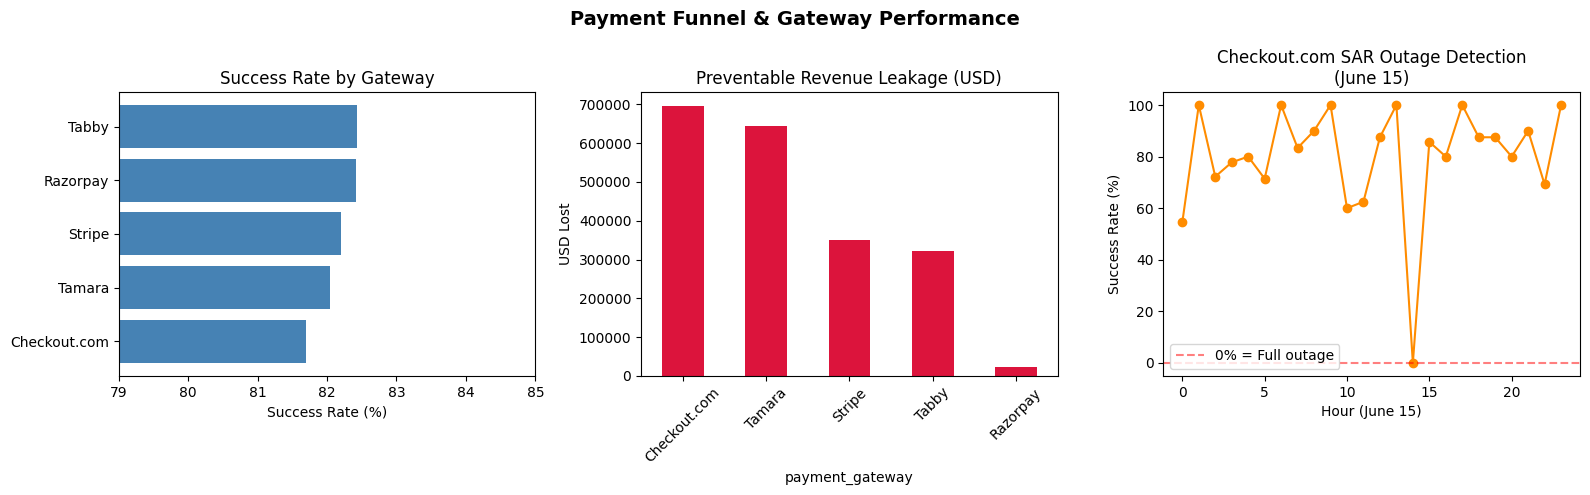

✅ Chart saved.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Payment Funnel & Gateway Performance', fontsize=14, fontweight='bold')

# Chart 1: Success rate by gateway
gateway_sr = df.groupby('payment_gateway')['status'].apply(
    lambda x: (x=='SUCCESS').mean()*100).sort_values()
axes[0].barh(gateway_sr.index, gateway_sr.values, color='steelblue')
axes[0].set_xlabel('Success Rate (%)')
axes[0].set_title('Success Rate by Gateway')
axes[0].set_xlim(79, 85)

# Chart 2: Revenue leakage
leakage['total_lost_usd'].plot(kind='bar', ax=axes[1], color='crimson')
axes[1].set_title('Preventable Revenue Leakage (USD)')
axes[1].set_ylabel('USD Lost')
axes[1].tick_params(axis='x', rotation=45)

# Chart 3: Hourly anomaly — Checkout.com on June 15
ckout_june15 = df[
    (df['payment_gateway'] == 'Checkout.com') &
    (df['timestamp'].dt.day == 15) &
    (df['currency'] == 'SAR')
].copy()
ckout_june15['hour'] = ckout_june15['timestamp'].dt.hour
hourly_sr = ckout_june15.groupby('hour')['status'].apply(
    lambda x: (x=='SUCCESS').mean()*100)
axes[2].plot(hourly_sr.index, hourly_sr.values, marker='o', color='darkorange')
axes[2].axhline(y=0, color='red', linestyle='--', alpha=0.5, label='0% = Full outage')
axes[2].set_xlabel('Hour (June 15)')
axes[2].set_ylabel('Success Rate (%)')
axes[2].set_title('Checkout.com SAR Outage Detection\n(June 15)')
axes[2].legend()

plt.tight_layout()
plt.savefig('payment_analysis.png', dpi=300)
plt.show()
print("✅ Chart saved.")

In [ ]:
print("""
=== KEY FINDINGS & RECOMMENDATIONS ===

1. CRITICAL: Checkout.com SAR outage — June 15, 14:00
   All 9 SAR transactions failed with SYSTEM_TIMEOUT in a 1-hour window.
   Recommendation: Implement automatic gateway failover to Tamara
   when Checkout.com SAR success rate drops below 70% in any 30-min window.

2. REVENUE LEAKAGE: $696,975 lost via Checkout.com technical failures
   This is preventable — GATEWAY_DOWN and SYSTEM_TIMEOUT are
   infrastructure failures, not user-side issues.
   Recommendation: SLA review with Checkout.com + penalty clauses
   for technical failure rates exceeding 2% monthly volume.

3. RAZORPAY is the most reliable gateway for INR (82.42% success rate)
   Recommendation: Route all high-value INR transactions (>₹3,000)
   exclusively through Razorpay as primary gateway.
""")


=== KEY FINDINGS & RECOMMENDATIONS ===

1. CRITICAL: Checkout.com SAR outage — June 15, 14:00
   All 9 SAR transactions failed with SYSTEM_TIMEOUT in a 1-hour window.
   Recommendation: Implement automatic gateway failover to Tamara
   when Checkout.com SAR success rate drops below 70% in any 30-min window.

2. REVENUE LEAKAGE: $696,975 lost via Checkout.com technical failures
   This is preventable — GATEWAY_DOWN and SYSTEM_TIMEOUT are
   infrastructure failures, not user-side issues.
   Recommendation: SLA review with Checkout.com + penalty clauses
   for technical failure rates exceeding 2% monthly volume.

3. RAZORPAY is the most reliable gateway for INR (82.42% success rate)
   Recommendation: Route all high-value INR transactions (>₹3,000)
   exclusively through Razorpay as primary gateway.

